In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.loc[df["tenure"] == 0, "TotalCharges"] = 0

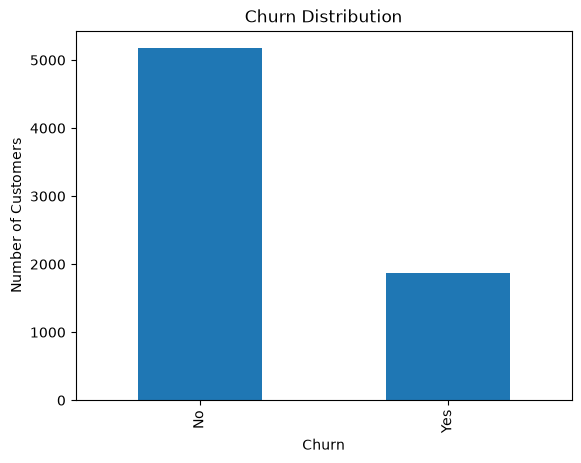

In [5]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

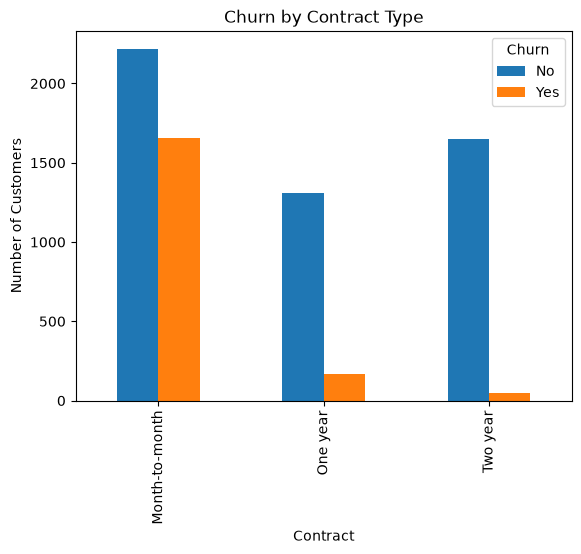

In [6]:
pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar")
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.show()

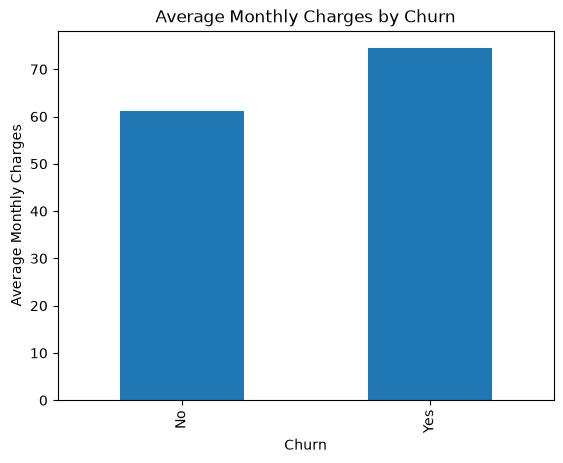

In [7]:
df.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.show()

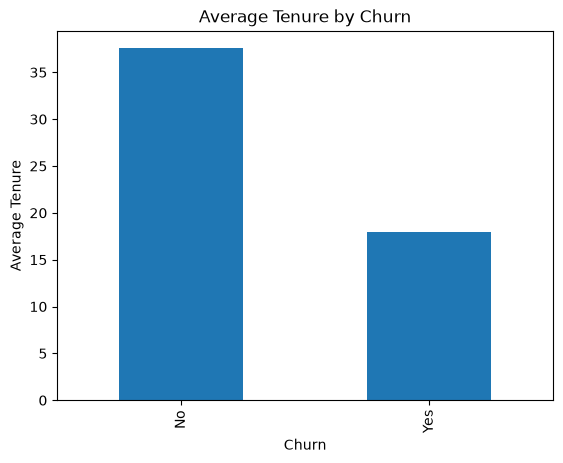

In [8]:
df.groupby("Churn")["tenure"].mean().plot(kind="bar")
plt.title("Average Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure")
plt.show()

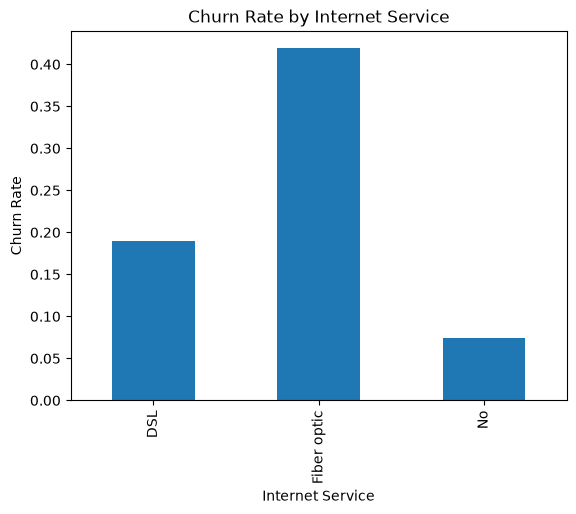

In [9]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.show()

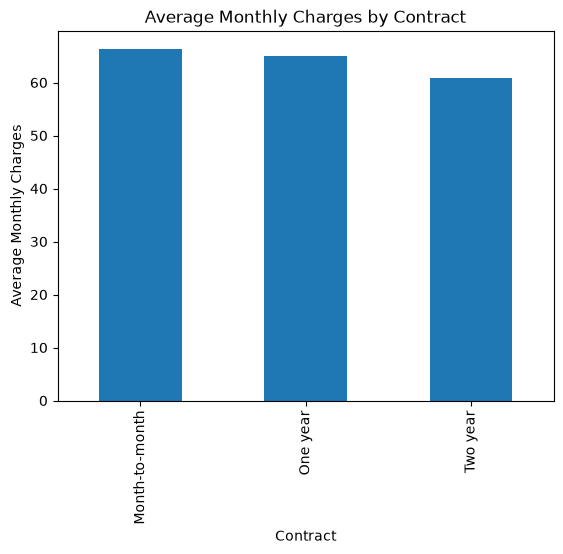

In [10]:
df.groupby("Contract")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Average Monthly Charges by Contract")
plt.xlabel("Contract")
plt.ylabel("Average Monthly Charges")
plt.show()

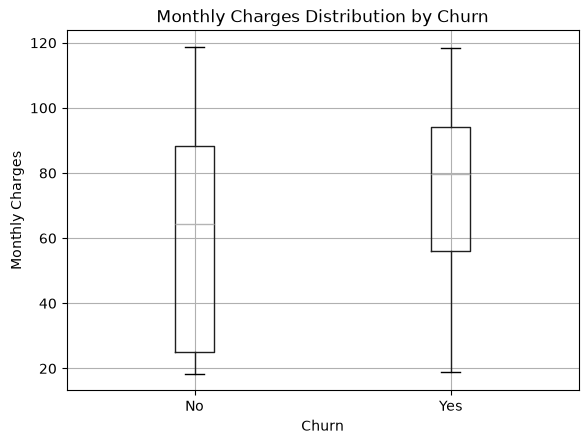

In [11]:
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

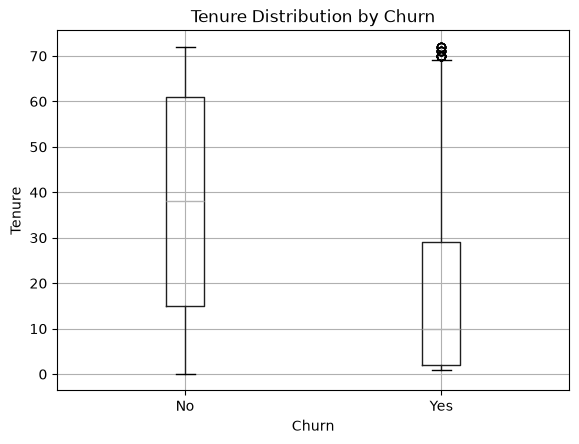

In [12]:
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

In [13]:
pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
)

Churn                                 No       Yes
Contract       InternetService                    
Month-to-month DSL              0.677841  0.322159
               Fiber optic      0.453947  0.546053
               No               0.811069  0.188931
One year       DSL              0.907018  0.092982
               Fiber optic      0.807050  0.192950
               No               0.975275  0.024725
Two year       DSL              0.980892  0.019108
               Fiber optic      0.927739  0.072261
               No               0.992163  0.007837

## Key EDA Findings

1. The dataset has moderate class imbalance:
   - No Churn: ~74.5%
   - Churn: ~26.5%

2. Month-to-month customers have a much higher churn rate than customers with one-year or two-year contracts.

3. Fiber optic customers show a higher churn rate than DSL and customers without internet service.

4. Customers who churn tend to have shorter tenure.

5. Customers who churn tend to have higher monthly charges.

6. The combination of Month-to-month contracts and Fiber optic service shows particularly high churn.

7. Tenure and TotalCharges are strongly positively correlated, which is expected because customers who stay longer usually accumulate higher total charges.